<a href="https://colab.research.google.com/github/Aline-17/Machine-Learning/blob/main/CP1_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 1 – Machine Learning & Statistical Computing

## Objetivo
O objetivo desta etapa é aplicar um modelo de aprendizado de máquina para classificar as amostras do dataset Iris em três categorias distintas de flores. Trata-se de um problema de classificação supervisionada, no qual o modelo aprende a partir de dados previamente rotulados.


In [26]:
# Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Parte 1 – Análise Estatística

Nesta etapa, analisamos os dados verificando valores nulos, estatísticas descritivas e possíveis outliers.
O dataset Iris foi carregado e estruturado em um DataFrame para facilitar a análise.

## Dataset Iris

O dataset Iris é amplamente utilizado em estudos de machine learning e contém informações sobre características físicas de flores, como comprimento e largura das sépalas e pétalas. A variável alvo representa três espécies diferentes de flores.

In [27]:
# Carregar dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [28]:
# Valores nulos
df.isnull().sum()


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [29]:
# Estatísticas descritivas
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [30]:
# Mediana, variância e desvio padrão
print("Mediana:\n", df.median())
print("\nVariância:\n", df.var())
print("\nDesvio padrão:\n", df.std())


Mediana:
 sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
target               1.00
dtype: float64

Variância:
 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
target               0.671141
dtype: float64

Desvio padrão:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
target               0.819232
dtype: float64


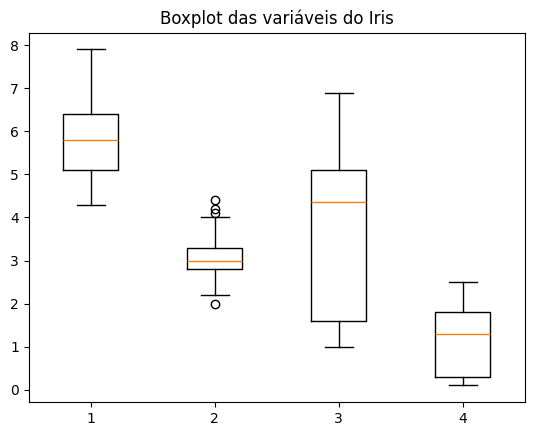

In [31]:
# Boxplot
plt.boxplot(df.drop('target', axis=1))
plt.title("Boxplot das variáveis do Iris")
plt.show()


## **O que é o KNN**

O algoritmo KNN (K-Nearest Neighbors) é um método baseado em instâncias que classifica novos dados com base na proximidade em relação aos dados já conhecidos. Para cada nova observação, o modelo calcula a distância entre essa observação e todas as demais do conjunto de treino, selecionando os k vizinhos mais próximos.

A classe atribuída à nova observação é determinada pela maioria entre esses vizinhos.



*   Ele usa distância (geralmente distância euclidiana)
*   Não cria “equação” → ele compara pontos
*   Funciona melhor com dados bem distribuídos



A métrica de distância utilizada por *padrão* é a distância euclidiana.

## Separação dos dados (X e y)

Inicialmente, os dados foram separados em variáveis independentes (X), que representam as características das flores, e variável dependente (y), que representa a classe a ser prevista.

X → entradas (features)

y → saída (target)

In [32]:
# Separar X e y
X = df.drop('target', axis=1)
y = df['target']


## Divisão em treino e teste

O conjunto de dados foi dividido em dois subconjuntos: treino (70%) e teste (30%). O conjunto de treino é utilizado para ajustar o modelo, enquanto o conjunto de teste é utilizado para avaliar sua capacidade de generalização.

In [33]:
# Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Importância do parâmetro k

O valor de k é um hiperparâmetro que influencia diretamente o desempenho do modelo.

Se k for muito pequeno (ex: 1):


*   Modelo muito sensível ao ruído
*   Pode ocorrer overfitting



Se k for muito grande:


*   Modelo perde precisão
*   Pode ocorrer underfitting



Ou seja:

Overfitting = decora demais


Underfitting = simplifica demais

## Treinamento e testes

Foram testados diferentes valores de k (1, 3, 5, 7 e 9) com o objetivo de identificar qual proporciona melhor desempenho na classificação.

Para cada valor de k, o modelo foi treinado com os dados de treino e avaliado com os dados de teste.

## Métrica de avaliação (Acurácia)

A acurácia foi utilizada como métrica de desempenho, representando a proporção de previsões corretas realizadas pelo modelo.

In [34]:
# Testar diferentes valores de K
k_values = [1, 3, 5, 7, 9]
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append((k, acc))


## Análise dos resultados

Os resultados obtidos mostraram variação na acurácia conforme o valor de k. Observou-se que valores intermediários apresentaram melhor desempenho, indicando um equilíbrio entre sensibilidade e generalização.

In [35]:
# Resultados
results_df = pd.DataFrame(results, columns=['K', 'Acurácia'])
results_df


,K,Acurácia
0,1,1.0
1,3,1.0
2,5,1.0
3,7,1.0
4,9,1.0


In [36]:
# Melhor K
best_k = results_df.loc[results_df['Acurácia'].idxmax()]
best_k


,0
K,1.0
Acurácia,1.0


## Interpretação do gráfico

O gráfico de acurácia em função de k permite visualizar claramente o comportamento do modelo. É possível observar que a acurácia tende a estabilizar ou diminuir após determinado valor de k.

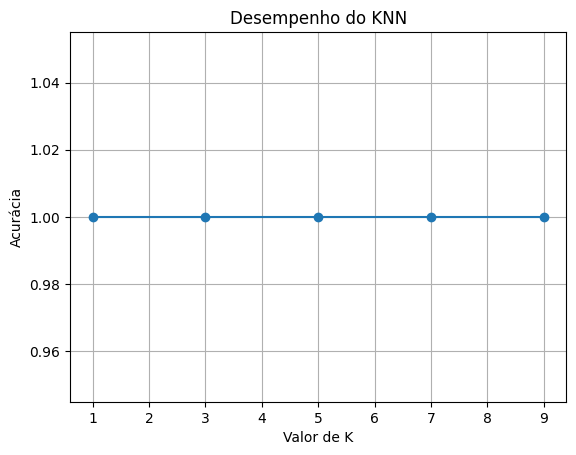

In [37]:
# Gráfico
plt.plot(results_df['K'], results_df['Acurácia'], marker='o')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.title('Desempenho do KNN')
plt.grid()
plt.show()


## Conclusão

O modelo KNN apresentou bom desempenho na classificação do dataset Iris. Foi possível observar que valores intermediários de K proporcionam melhor equilíbrio entre precisão e generalização.

A escolha adequada do valor de k foi essencial para alcançar bons resultados, evidenciando a importância do ajuste de hiperparâmetros em modelos de machine learning.